In [97]:
import pandas as pd
import numpy as np

In [98]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [99]:
import statsmodels.formula.api as smf

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [101]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [102]:
df = pd.read_excel(fpath + '\\6.0_database_variables.xlsx')

In [103]:
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'week(1=free days)': 'weekday_type'})

In [104]:
# remove outliers
df = df[(np.abs(stats.zscore(df['sleep_duration(h)_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['midpoint_h_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]
#df = df[(np.abs(stats.zscore(df['Fragmentation Index (FI)'])) < 3)]

In [105]:
df = df.drop('sunrise_time(USA)', axis=1)
df = df.drop('sunrise (USA), hours', axis=1)
df = df.drop('sunset (USA), hours', axis=1)
df = df.drop('sunset_time(USA)', axis=1)
df = df.drop('photoperiod (h, USA)', axis=1)

In [106]:
# Define the start date
start_date = pd.to_datetime('2022-02-01')

In [107]:
# Function to count the week of the year from the start date 2022-01-01
def calculate_week_of_year(start_datetime):
    return (start_datetime - start_date).days // 7 + 5

# Apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [108]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [109]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [110]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)_UTC'] = df['sleep_duration(h)_UTC'].astype(float)
df['sleep_duration_work_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'free days')

In [111]:
# sleep loss
# if sleep duration work > sleep duration free -> (sleep duration on work days - sleep duration on free days) - day of the week
# if sleep duration work < sleep duration free -> (sleep duration on work days - sleep duration on free days) - free days
df['sleep_loss_UTC'] = (df['sleep_duration_work_days_UTC'] - df['sleep_duration_free_days_UTC']) * (df['sleep_duration_work_days_UTC'] > df['sleep_duration_free_days_UTC']) + \
    (df['sleep_duration_work_days_UTC'] - df['sleep_duration_free_days_UTC']) * (df['sleep_duration_work_days_UTC'] < df['sleep_duration_free_days_UTC'])

In [112]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [113]:
data_jetlag_UTC = df #df for weekly jetlag analysis

In [114]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag_UTC = data_jetlag_UTC.groupby(['location', 'week_of_year', 'weekday_type'])['midpoint_h_UTC'].mean().unstack()

In [115]:
weekly_means_jetlag_UTC['jet lag_UTC'] = weekly_means_jetlag_UTC['free days'] - weekly_means_jetlag_UTC['work days']

In [116]:
# add a column with the location
weekly_means_jetlag_UTC['location'] = weekly_means_jetlag_UTC.index.get_level_values(0)

In [117]:
weekly_means_jetlag_UTC.to_excel(fpath + '\\weekly_means_jetlag_UTC.xlsx')

In [118]:
df = df.rename(columns={'sleep_duration(h)_UTC': 'sleep_duration_UTC'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

In [119]:
# Adding a 'season' column to the dataset based on the 'date' column
# Defining seasons based on months: 
# Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)
def assign_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [120]:
# Applying the function to create a season column
df_workdays['season'] = df_workdays['date'].apply(assign_season)
df_freedays['season'] = df_freedays['date'].apply(assign_season)
df['season'] = df['date'].apply(assign_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_21444\2974399819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays['season'] = df_workdays['date'].apply(assign_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_21444\2974399819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays['season'] = df_freedays['date'].apply(assign_season)


In [121]:
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] # add a column with the photoperiod for the UK
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_21444\1293994927.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] # add a column with the photoperiod for the UK


In [122]:
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_21444\1486412571.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


# EDA

In [123]:
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

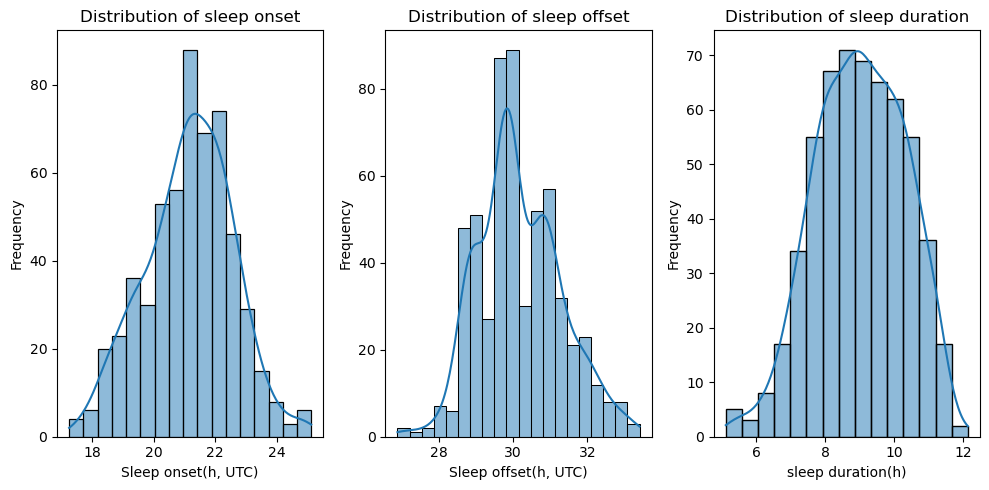

In [124]:
# Distribution 
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep offset")
plt.xlabel("Sleep offset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

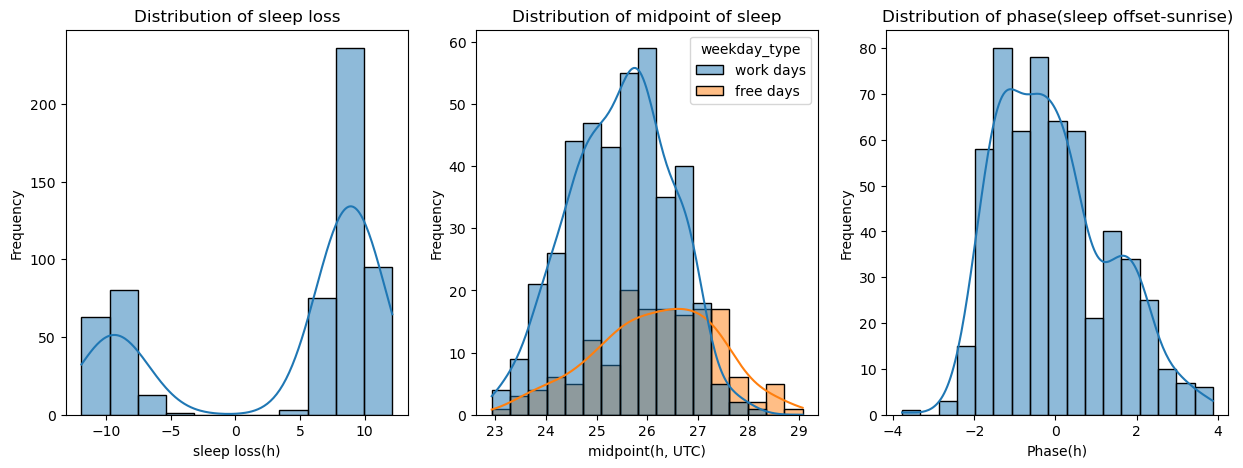

<Figure size 640x480 with 0 Axes>

In [125]:
# Distribution 
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_loss_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep loss")
plt.xlabel("sleep loss(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='midpoint_h_UTC', hue='weekday_type', kde=True)
plt.title("Distribution of midpoint of sleep")
plt.xlabel("midpoint(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1,3,3)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(sleep offset-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")
plt.show()

plt.tight_layout()
plt.show()

In [126]:
# test normality of the data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration_UTC'])
shapiro_test_sleeploss = stats.shapiro(df['sleep_loss_UTC'])
shapiro_test_midpoint = stats.shapiro(df['midpoint_h_UTC'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal_UTC'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal_UTC'])
shapiro_test_phase = stats.shapiro(df['phase'])
shapiro_test_fi = stats.shapiro(df['Fragmentation Index (FI)'])

In [127]:
shapiro_results_descriptive = pd.DataFrame({
    'Variable': ['sleep_duration(h)', 'sleep_loss_UTC', 'midpoint_h_UTC', 'sleep_start_decimal_UTC', 'sleep_end_decimal_UTC', 'phase(sleepoffset-sunrise)', 'Fragmentation Index'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_sleeploss, shapiro_test_midpoint, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase, shapiro_test_fi]
})

In [128]:
shapiro_results_descriptive

,Variable,Shapiro-Wilk test
0,sleep_duration(h),"(0.9902246610911858, 0.0008226033160291848)"
1,sleep_loss_UTC,"(0.6997461052790972, 1.5493129771511592e-30)"
2,midpoint_h_UTC,"(0.9966098081502522, 0.27825571498290286)"
3,sleep_start_decimal_UTC,"(0.9938769987889519, 0.021848420182686012)"
4,sleep_end_decimal_UTC,"(0.9836545244937268, 5.6566874049762885e-06)"
5,phase(sleepoffset-sunrise),"(0.9661064505005437, 3.7966420613702094e-10)"
6,Fragmentation Index,"(nan, nan)"


In [129]:
#shapiro of midpoint free days and work days
shapiro_test_midpoint_free = stats.shapiro(df[df['weekday_type'] == 'free days']['midpoint_h_UTC'])
shapiro_test_midpoint_work = stats.shapiro(df[df['weekday_type'] == 'work days']['midpoint_h_UTC'])

In [130]:
shapiro_results_free_work = pd.DataFrame({
    'Weekday type': ['free days', 'work days'],
    'Shapiro-Wilk test': [shapiro_test_midpoint_free, shapiro_test_midpoint_work]
})

In [131]:
shapiro_results_free_work

,Weekday type,Shapiro-Wilk test
0,free days,"(0.9894810197523596, 0.29179366919766936)"
1,work days,"(0.9929247333891301, 0.050973709866609325)"


In [132]:
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [133]:
df_grouped_weekday = df.groupby('weekday_type').describe()
df_grouped_weekday = df_grouped_weekday.transpose()

In [134]:
df_grouped_location_weekday = df.groupby(['location', 'weekday_type']).describe()
df_grouped_location_weekday = df_grouped_location_weekday.transpose()

In [135]:
# compare the midpoint, duration and phase between the two locations
ttest_midpoint_workdays_loc = stats.ttest_ind(df_workdays[df_workdays['location'] == 'ITA']['midpoint_h_UTC'], df_workdays[df_workdays['location'] == 'UK']['midpoint_h_UTC'])
ttest_midpoint_freedays_loc = stats.ttest_ind(df_freedays[df_freedays['location'] == 'ITA']['midpoint_h_UTC'], df_freedays[df_freedays['location'] == 'UK']['midpoint_h_UTC'])
utest_duration_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_duration_UTC'], df[df['location'] == 'UK']['sleep_duration_UTC'])
utest_sleeploss_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_loss_UTC'], df[df['location'] == 'UK']['sleep_loss_UTC'])   
utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal_UTC'], df[df['location'] == 'UK']['sleep_start_decimal_UTC'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal_UTC'], df[df['location'] == 'UK']['sleep_end_decimal_UTC'])
utest_fragmentation_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['Fragmentation Index (FI)'], df[df['location'] == 'UK']['Fragmentation Index (FI)'])

# compare the midpoint, duration and phase between work days and free days
ttest_midpoint_week = stats.ttest_ind(df[df['weekday_type'] == 'work days']['midpoint_h_UTC'], df[df['weekday_type'] == 'free days']['midpoint_h_UTC'])
utest_duration_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_duration_UTC'], df[df['weekday_type'] == 'free days']['sleep_duration_UTC'])
utest_sleeploss_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_loss_UTC'], df[df['weekday_type'] == 'free days']['sleep_loss_UTC'])
utest_phase_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['phase'], df[df['weekday_type'] == 'free days']['phase'])
utest_start_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_start_decimal_UTC'], df[df['weekday_type'] == 'free days']['sleep_start_decimal_UTC'])
utest_end_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_end_decimal_UTC'], df[df['weekday_type'] == 'free days']['sleep_end_decimal_UTC'])
utest_fragmentation_week = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['Fragmentation Index (FI)'], df[df['weekday_type'] == 'free days']['Fragmentation Index (FI)'])

In [136]:
print('T test results for location')
print('Midpoint_work:', ttest_midpoint_workdays_loc)
print('Midpoint_free:', ttest_midpoint_freedays_loc)
print('U test results for location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Sleep_duration:', utest_duration_loc)
print('Sleep_loss:', utest_sleeploss_loc)
print('Phase:', utest_phase_loc)
print('Fragmentation Index:', utest_fragmentation_loc)

T test results for location
Midpoint_work: TtestResult(statistic=-7.002582947406899, pvalue=1.044280679209457e-11, df=407.0)
Midpoint_free: TtestResult(statistic=-3.8479181254840364, pvalue=0.00017370196992224848, df=155.0)
U test results for location
Sleep_onset: MannwhitneyuResult(statistic=29056.0, pvalue=6.015842573800659e-07)
Sleep_offset: MannwhitneyuResult(statistic=24049.5, pvalue=2.6869544574564792e-14)
Sleep_duration: MannwhitneyuResult(statistic=37477.0, pvalue=0.561399767835371)
Sleep_loss: MannwhitneyuResult(statistic=36996.5, pvalue=0.40518765457326333)
Phase: MannwhitneyuResult(statistic=23915.0, pvalue=1.5550312393417045e-14)
Fragmentation Index: MannwhitneyuResult(statistic=nan, pvalue=nan)


In [137]:
print('T test results for free/work days:') 
print('Midpoint:', ttest_midpoint_week)
print('U test results for free/work days:')
print('Sleep_onset:', utest_start_week)
print('Sleep_offset:', utest_end_week)
print('Sleep_duration:', utest_duration_week)
print('Sleep_loss:', utest_sleeploss_week)
print('Phase:', utest_phase_week)
print('Fragmentation Index:', utest_fragmentation_week)

T test results for free/work days:
Midpoint: TtestResult(statistic=-7.1766001931353305, pvalue=2.2617971926824492e-12, df=564.0)
U test results for free/work days:
Sleep_onset: MannwhitneyuResult(statistic=25876.5, pvalue=0.00034838522139971713)
Sleep_offset: MannwhitneyuResult(statistic=18376.5, pvalue=3.2166591077253687e-15)
Sleep_duration: MannwhitneyuResult(statistic=26295.5, pvalue=0.0008504826587601188)
Sleep_loss: MannwhitneyuResult(statistic=64213.0, pvalue=7.260809316503503e-76)
Phase: MannwhitneyuResult(statistic=20575.5, pvalue=3.6001698133751243e-11)
Fragmentation Index: MannwhitneyuResult(statistic=nan, pvalue=nan)


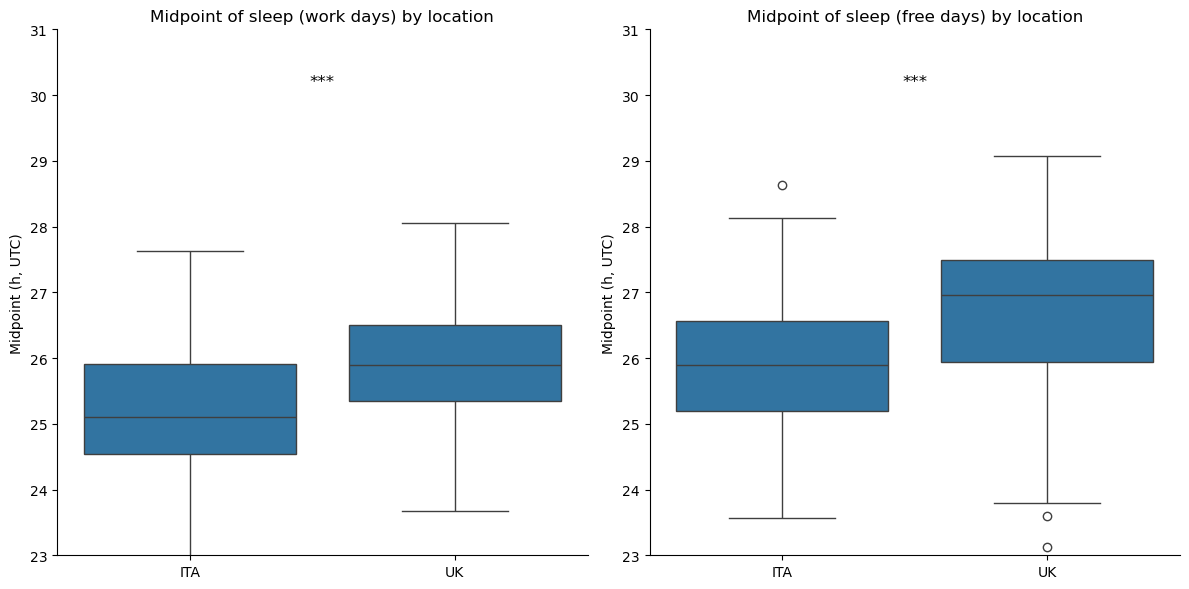

In [138]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='location', y='midpoint_h_UTC', data=df_workdays, ax=ax[0])
ax[0].set_title('Midpoint of sleep (work days) by location')
ax[0].set_ylabel('Midpoint (h, UTC)')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_locator(MultipleLocator(1))
ax[0].set_ylim(23, 31)
#add a significance line of ** for the p-value < 0.01
if ttest_midpoint_workdays_loc.pvalue < 0.001:
    ax[0].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 

sns.boxplot(x='location', y='midpoint_h_UTC', data=df_freedays, ax=ax[1])
ax[1].set_title('Midpoint of sleep (free days) by location')
ax[1].set_ylabel('Midpoint (h, UTC)')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_locator(MultipleLocator(1))
ax[1].set_ylim(ax[0].get_ylim())

#add a significance line of  for the p-value < 0.05
if ttest_midpoint_freedays_loc.pvalue < 0.001:
    ax[1].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) 
    
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.tight_layout()
plt.show()

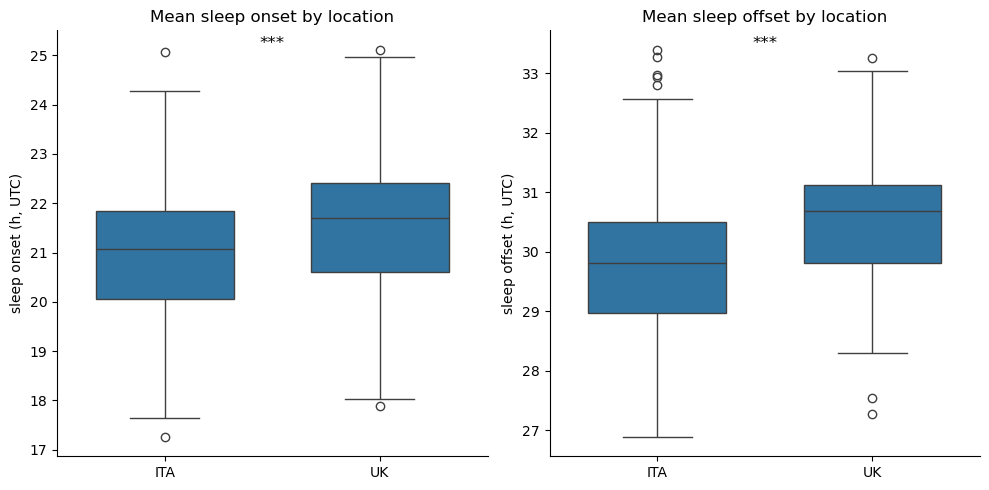

In [139]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal_UTC', data=df, gap=0.2)
plt.title("Mean sleep onset by location")
plt.xlabel("")
plt.ylabel("sleep onset (h, UTC)")
#add a significance line to the subplot
if utest_start_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal_UTC', data=df, gap=0.2)
plt.title("Mean sleep offset by location")
plt.xlabel("")
plt.ylabel("sleep offset (h, UTC)")
#add a significance line 
if utest_end_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

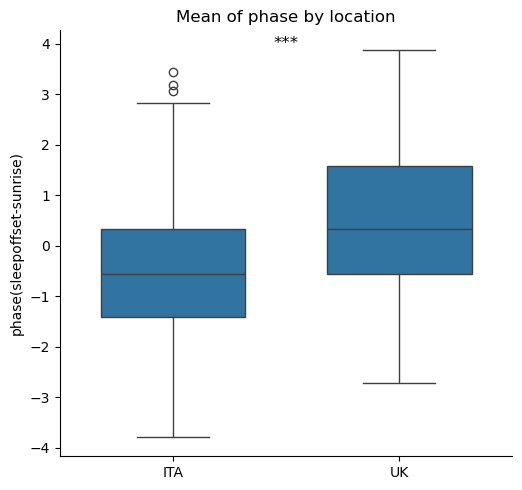

In [140]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='phase', data=df, gap=0.2)
plt.title("Mean of phase by location")
plt.xlabel("")
plt.ylabel("phase(sleepoffset-sunrise)")
#add a significance line to the subplot
if utest_phase_loc.pvalue < 0.001:
    plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

#plt.subplot(1, 2, 2)
#sns.boxplot(x='location', y='Fragmentation Index (FI)', data=df, gap=0.2)
#plt.title("Fragmentation Index (FI) by location")
#plt.xlabel("")
#plt.ylabel("FI")
#add a significance line 
#if utest_fragmentation_loc.pvalue < 0.001:
#    plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

Fragmentation Index: The sum of the ‘Mobile time (%)’ and the ‘Immobile bouts <=1min (%)’. This is an indication of the degree of fragmentation of the sleep period, and can be used as an indication of sleep quality (or the lack of it).

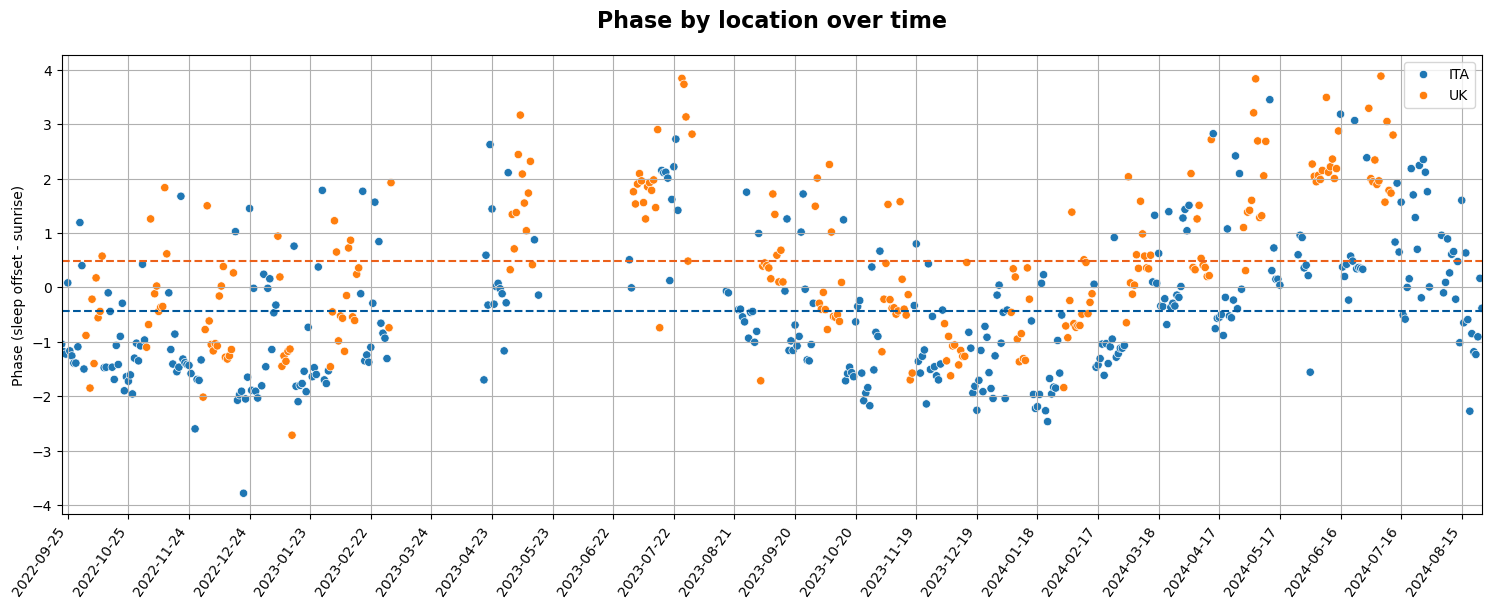

In [141]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', data=df)
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())

# get the current axes then set the x-axis major locator
# plot.gca()=ax if set ax = plt.gca()
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) 

#add the mean of the phase for the two locations
plt.axhline(df[df['location'] == 'ITA']['phase'].mean(), color='#00589c', linestyle='--', label='ITA mean')
plt.axhline(df[df['location'] == 'UK']['phase'].mean(), color='#ec611a', linestyle='--', label='UK mean')

plt.show()

_Jetlag_

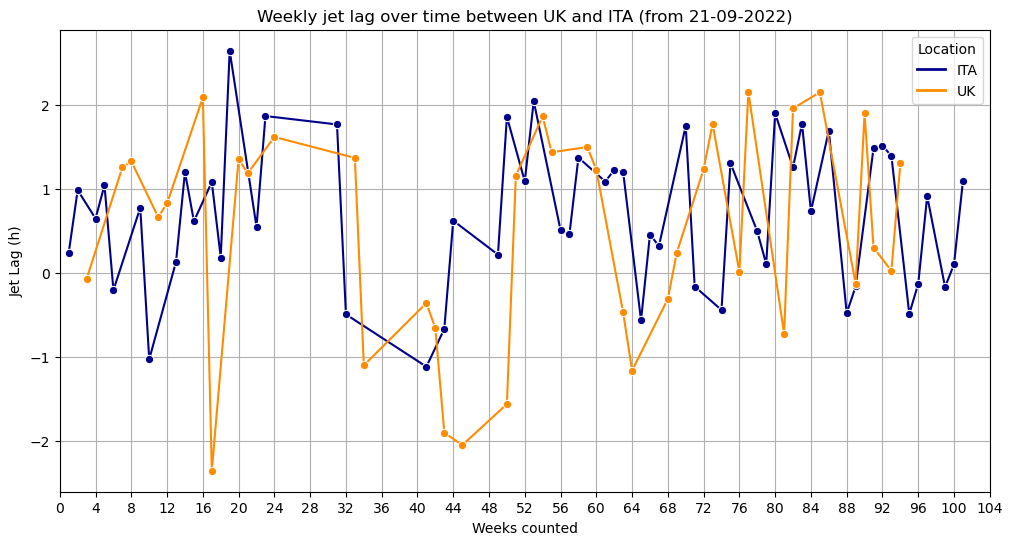

In [142]:
# Plot the weekly jet lag between UK and ITA
plt.figure(figsize=(12, 6))
sns.lineplot(x='week_of_year', y='jet lag_UTC', hue='location', data=weekly_means_jetlag_UTC, marker='o', palette=['darkblue', 'darkorange'])
plt.title('Weekly jet lag over time between UK and ITA (from 21-09-2022)')
plt.xlabel('Weeks counted')
plt.ylabel('Jet Lag (h)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange', lw=2)])
plt.grid(True)
plt.xlim(0, 104)
plt.gca().xaxis.set_major_locator(MultipleLocator(4)) 
plt.xticks()
plt.show()

In [143]:
# Remove NaN values before performing the Shapiro-Wilk test
jetlag_no_nan = weekly_means_jetlag_UTC['jet lag_UTC'].dropna()

In [144]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_no_nan)

In [145]:
shapiro_test_jetlag

ShapiroResult(statistic=0.9658908356235015, pvalue=0.015610375282271051)

In [146]:
# Perform a Mann whitney test to compare the jet lag between the two locations
utest_jetlag = stats.mannwhitneyu(weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'ITA']['jet lag_UTC'].dropna(), weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'UK']['jet lag_UTC'].dropna())

In [147]:
print('Results for jet lag:')
print(utest_jetlag)

Results for jet lag:
MannwhitneyuResult(statistic=1049.5, pvalue=0.9750606867138256)


_Seasonal effect_

In [148]:
df = df.dropna(subset=['sleep_duration_UTC'])
df = df.dropna(subset=['phase'])

In [149]:
anova_midpoint_work_season1 = ols('midpoint_h_UTC ~ C(season)', data=df_workdays).fit()

In [150]:
anova_midpoint_free_season1 = ols('midpoint_h_UTC ~ C(season)', data=df_freedays).fit()

In [151]:
anova_midpoint_work_result_season1 = sm.stats.anova_lm(anova_midpoint_work_season1, typ=3) #fit the ANOVA model and get the results

In [152]:
anova_midpoint_free_result_season1 = sm.stats.anova_lm(anova_midpoint_free_season1, typ=3)

In [153]:
print("\nANOVA_midpoint work Results:")
print(anova_midpoint_work_result_season1)
print("\nANOVA_midpoint free Results:")
print(anova_midpoint_free_result_season1)


ANOVA_midpoint work Results:
                 sum_sq     df             F        PR(>F)
Intercept  72497.076272    1.0  91065.415409  0.000000e+00
C(season)     75.113393    3.0     31.450613  2.700521e-18
Residual     322.420051  405.0           NaN           NaN

ANOVA_midpoint free Results:
                 sum_sq     df             F         PR(>F)
Intercept  29897.380563    1.0  24463.907714  1.022711e-170
C(season)     38.872183    3.0     10.602551   2.249227e-06
Residual     186.981544  153.0           NaN            NaN


In [154]:
# Kruskal-Wallis test 
kw_sleep_duration_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_duration_UTC'], df[df['season'] == 'Spring']['sleep_duration_UTC'], df[df['season'] == 'Summer']['sleep_duration_UTC'], df[df['season'] == 'Autumn']['sleep_duration_UTC'])
kw_phase_season = stats.kruskal(df[df['season'] == 'Winter']['phase'], df[df['season'] == 'Spring']['phase'], df[df['season'] == 'Summer']['phase'], df[df['season'] == 'Autumn']['phase'])
kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal_UTC'], df[df['season'] == 'Spring']['sleep_start_decimal_UTC'], df[df['season'] == 'Summer']['sleep_start_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_start_decimal_UTC'])
kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal_UTC'], df[df['season'] == 'Spring']['sleep_end_decimal_UTC'], df[df['season'] == 'Summer']['sleep_end_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_end_decimal_UTC'])

In [155]:
print('Results for Kruskal-Wallis test for the sleep duration by season')
print(kw_sleep_duration_season)
print('Results for Kruskal-Wallis test for the phase by season')
print(kw_phase_season)
print('Results for Kruskal-Wallis test for the sleep onset by season')
print(kw_start_season)
print('Results for Kruskal-Wallis test for the sleep offset by season')
print(kw_end_season)

Results for Kruskal-Wallis test for the sleep duration by season
KruskalResult(statistic=1.5978437208009528, pvalue=0.6598788403583598)
Results for Kruskal-Wallis test for the phase by season
KruskalResult(statistic=205.67649777702235, pvalue=2.5034834728697753e-44)
Results for Kruskal-Wallis test for the sleep onset by season
KruskalResult(statistic=53.86323177380167, pvalue=1.2000065049226613e-11)
Results for Kruskal-Wallis test for the sleep offset by season
KruskalResult(statistic=88.20097144611152, pvalue=5.332390398690246e-19)


In [156]:
# perform a Tukey HSD test to compare the means
tukey_results_season1 = pairwise_tukeyhsd(df_workdays['midpoint_h_UTC'], df_workdays['season'])
print(tukey_results_season1)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring  -0.0285 0.9962 -0.3606 0.3036  False
Autumn Summer  -0.0734 0.9393 -0.4021 0.2554  False
Autumn Winter   0.8959    0.0  0.5984 1.1934   True
Spring Summer  -0.0449 0.9879 -0.3991 0.3093  False
Spring Winter   0.9244    0.0   0.599 1.2498   True
Summer Winter   0.9693    0.0  0.6473 1.2912   True
---------------------------------------------------


In [157]:
# Perform a Tukey HSD test to compare the means
tukey_results_season4 = pairwise_tukeyhsd(df['phase'], df['season'])
print(tukey_results_season4)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.2648    0.0  0.9174  1.6123   True
Autumn Summer   1.7175    0.0  1.3743  2.0606   True
Autumn Winter  -0.2813 0.0912 -0.5916   0.029  False
Spring Summer   0.4526 0.0094  0.0821  0.8232   True
Spring Winter  -1.5461    0.0 -1.8864 -1.2058   True
Summer Winter  -1.9987    0.0 -2.3347 -1.6628   True
----------------------------------------------------


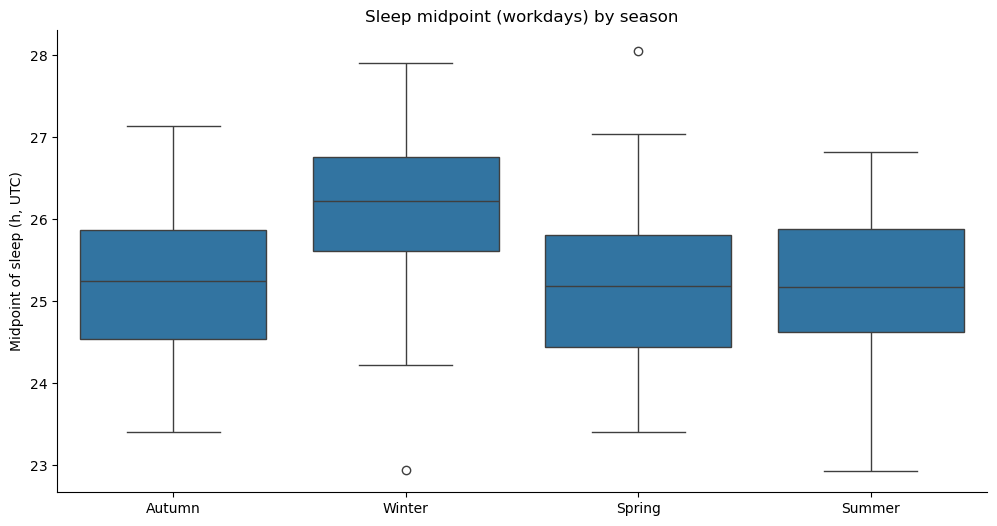

In [158]:
# Sleep Midpoint (work) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h_UTC', data=df_workdays)
plt.title('Sleep midpoint (workdays) by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of sleep (h, UTC)')
plt.xlabel('')
sns.despine()
plt.grid(False)
#bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

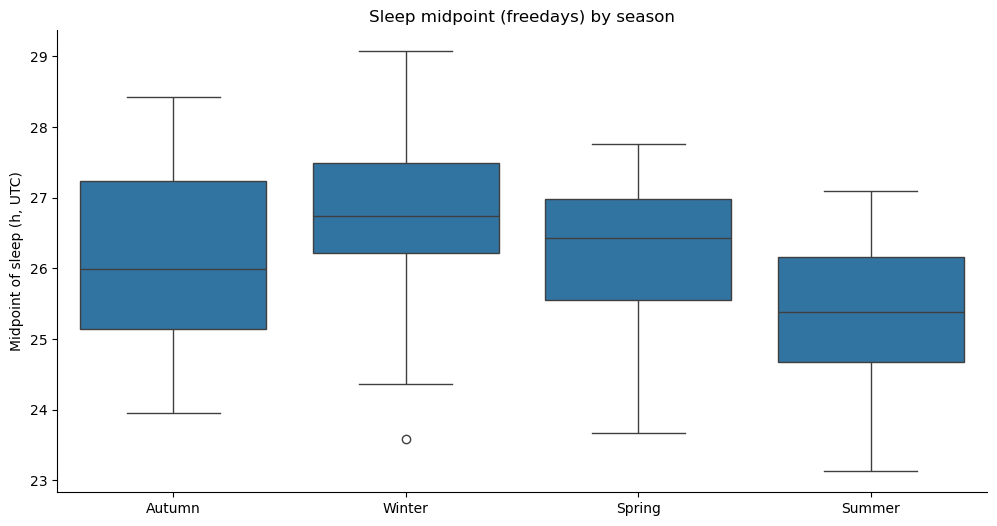

In [159]:
# Sleep Midpoint (free) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midpoint_h_UTC', data=df_freedays)
plt.title('Sleep midpoint (freedays) by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of sleep (h, UTC)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

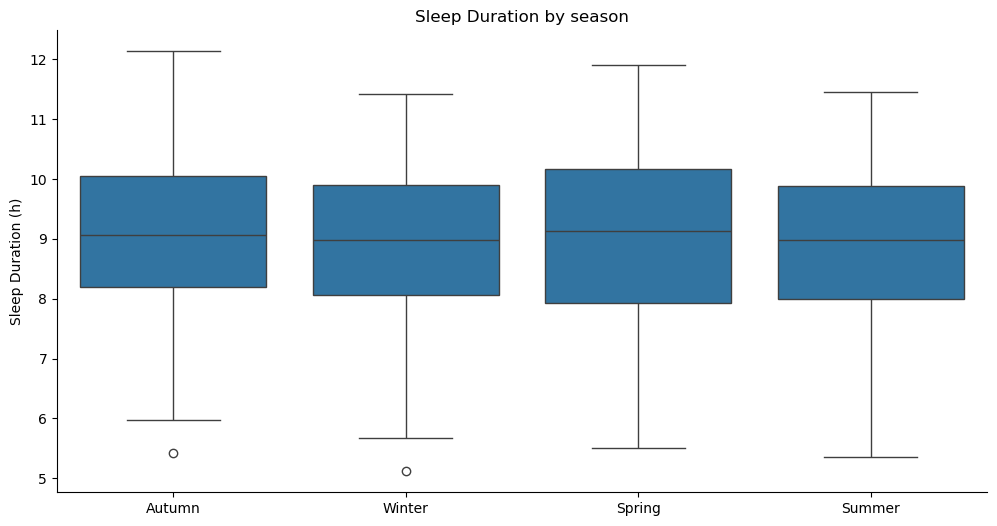

In [160]:
# Sleep Duration by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_duration_UTC', data=df)
plt.title('Sleep Duration by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Sleep Duration (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

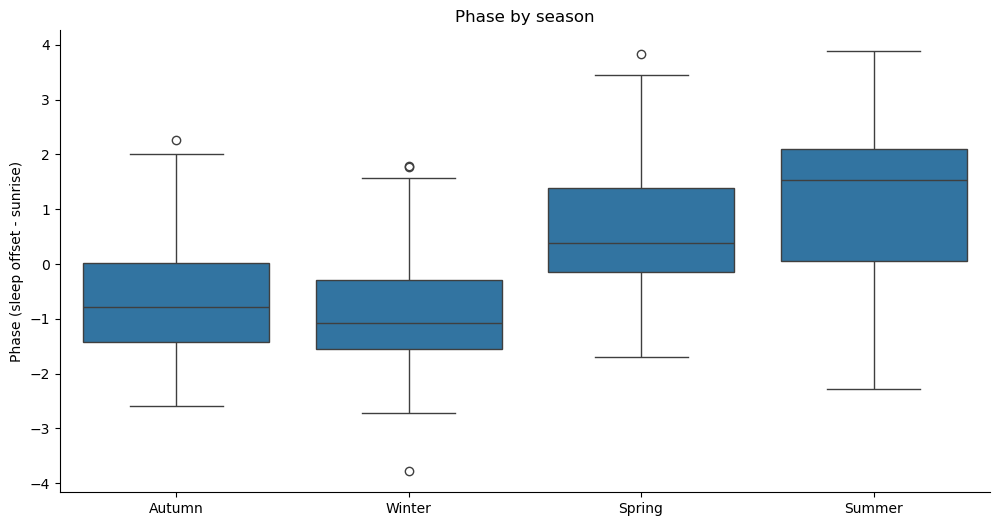

In [161]:
# Sleep Phase by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df)
plt.title('Phase by season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
sns.despine()
plt.grid(False)
# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

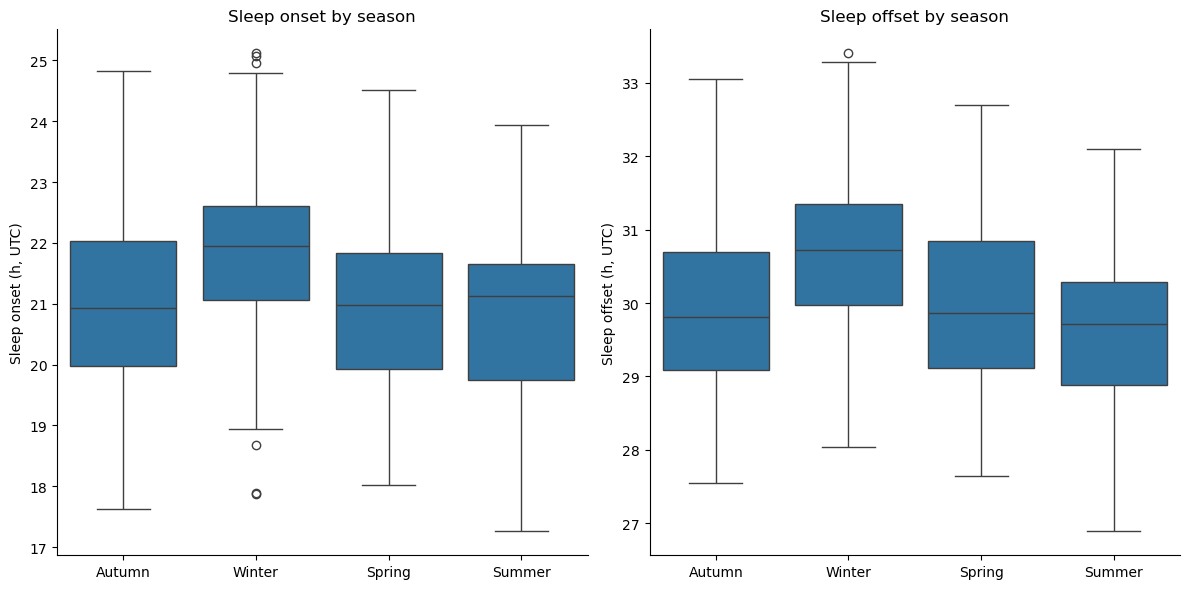

In [162]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='season', y='sleep_start_decimal_UTC', data=df)
plt.title('Sleep onset by season')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')

plt.subplot(1, 2, 2)
sns.boxplot(x='season', y='sleep_end_decimal_UTC', data=df)
plt.title('Sleep offset by season')
plt.ylabel('Sleep offset (h, UTC)')
plt.xlabel('')

# bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

_Photoperiod and sleep-wake pattern_

In [163]:
correlation_test1 = stats.pearsonr(df_workdays['midpoint_h_UTC'], df_workdays['photoperiod'])
correlation_test2 = stats.pearsonr(df_freedays['midpoint_h_UTC'], df_freedays['photoperiod'])
correlation_test3 = stats.spearmanr(df['sleep_start_decimal_UTC'], df['photoperiod'])
correlation_test4 = stats.spearmanr(df['sleep_end_decimal_UTC'], df['photoperiod'])

In [164]:
# Extract the coefficients and p-values from the correlation test results
pearson_coeff = [correlation_test1.statistic, correlation_test2.statistic, correlation_test3.statistic, correlation_test4.statistic]
p_values = [correlation_test1.pvalue, correlation_test2.pvalue, correlation_test3.pvalue, correlation_test4.pvalue]

# Create a DataFrame with the results
correlation_results = pd.DataFrame({
    'Variables': ['midpoint (work) UTC vs photoperiod', 'midpoint (free) UTC vs photoperiod', 'sleep onset UTC vs photoperiod', 'sleep offset UTC vs photoperiod'],
    'Coefficient': pearson_coeff,
    'P-value': p_values
})

correlation_results

,Variables,Coefficient,P-value
0,midpoint (work) UTC vs photoperiod,-0.381068,1.389815e-15
1,midpoint (free) UTC vs photoperiod,-0.390352,4.326967e-07
2,sleep onset UTC vs photoperiod,-0.285606,4.374961e-12
3,sleep offset UTC vs photoperiod,-0.390613,4.510522e-22


_Midsleep vs days after flight_

In [165]:
midsleep_bydays_after_flight = df.dropna(subset=['midpoint_h_UTC', 'location', 'day_after_flight'])
midsleep_bydays_after_flight = midsleep_bydays_after_flight[midsleep_bydays_after_flight['day_after_flight'] <= 15]

In [166]:
midsleep_bydays_after_flight['location'] = midsleep_bydays_after_flight['location'].map({'ITA': 0, 'UK': 1})

In [211]:
midsleep_bydays_after_flight.ttest = stats.ttest_ind(midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 0]['midpoint_h_UTC'], midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 1]['midpoint_h_UTC'])

midsleep_bydays_after_flight.ttest

C:\Users\gg00642\AppData\Local\Temp\ipykernel_21444\1424359682.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  midsleep_bydays_after_flight.ttest = stats.ttest_ind(midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 0]['midpoint_h_UTC'], midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 1]['midpoint_h_UTC'])


TtestResult(statistic=-7.309685235205013, pvalue=1.0492726395687912e-12, df=507.0)

In [167]:
# test the effect of the location and the days after flight on the midpoint of sleep with a anova repeated measure
# ITA is the reference category
anova_midpoint_days_after_flight = ols('midpoint_h_UTC ~ C(location) + C(day_after_flight) + C(location):C(day_after_flight)', data=midsleep_bydays_after_flight).fit()

anova_midpoint_days_after_flight_result = sm.stats.anova_lm(anova_midpoint_days_after_flight, typ=3)

anova_midpoint_days_after_flight_result

,sum_sq,df,F,PR(>F)
Intercept,14266.286787,1.0,13342.113996,0.000000
C(location),0.009425,1.0,0.008815,0.925239
C(day_after_flight),43.701072,14.0,2.919293,0.000283
C(location):C(day_after_flight),15.541286,14.0,1.038180,0.413394
Residual,512.179057,479.0,NaN,NaN


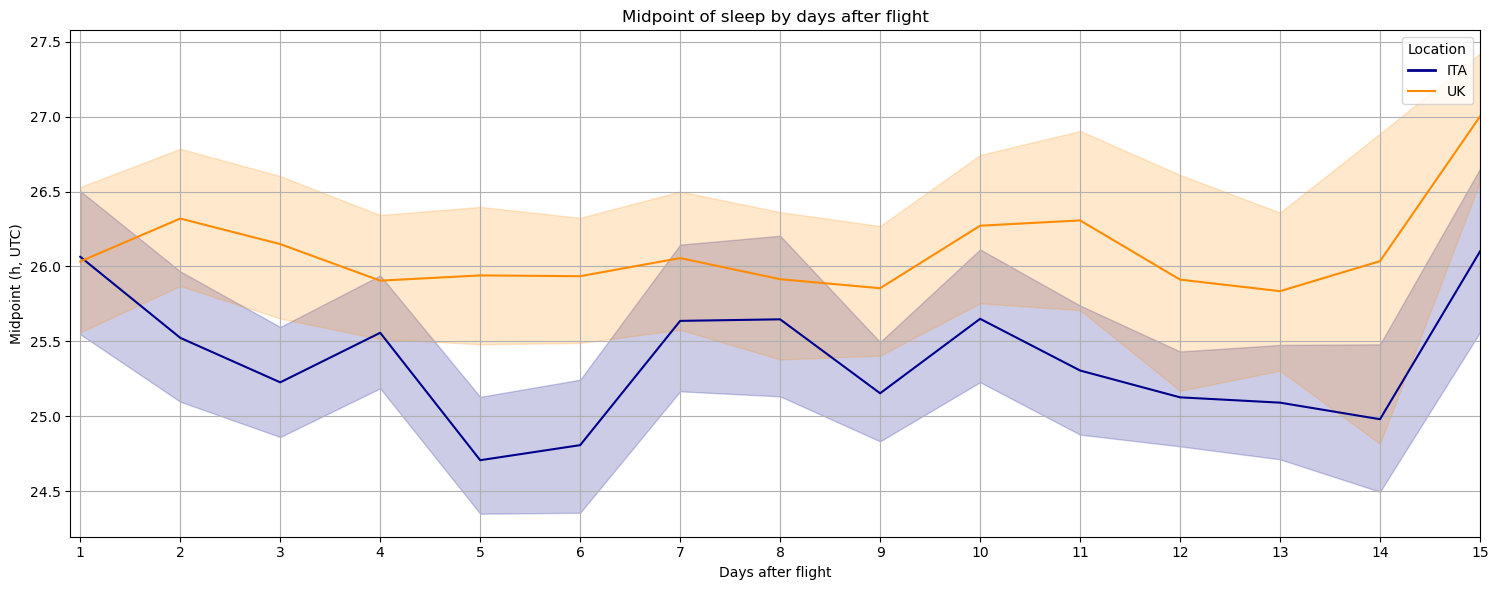

In [215]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='day_after_flight', y='midpoint_h_UTC', hue='location', data=midsleep_bydays_after_flight, palette=['darkblue', 'darkorange'])
plt.title('Midpoint of sleep by days after flight')
plt.xlabel('Days after flight')
plt.ylabel('Midpoint (h, UTC)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.xlim(0.9, 15)

plt.gca().xaxis.set_major_locator(MultipleLocator(1)) 

plt.show()

In [216]:
#weights of the anova model
weights = anova_midpoint_days_after_flight.params

In [219]:
#pritn the weights as a table
weights_table = pd.DataFrame(weights, columns=['Weights'])
weights_table

,Weights
Intercept,26.064286
C(location)[T.1],-0.031184
C(day_after_flight)[T.2],-0.541270
C(day_after_flight)[T.3],-0.838492
C(day_after_flight)[T.4],-0.507540
C(day_after_flight)[T.5],-1.358452
C(day_after_flight)[T.6],-1.257827
C(day_after_flight)[T.7],-0.428036
C(day_after_flight)[T.8],-0.417619
C(day_after_flight)[T.9],-0.911508


_Phase by location, time and photoperiod_

In [169]:
data_phase = df.dropna(subset=['phase', 'location', 'date', 'photoperiod'])

In [170]:
data_phase['location'] = data_phase['location'].map({'ITA': 0, 'UK': 1}) # convert the location to numerical values

In [171]:
# Converting date to numerical values (days since the start of the observation period)
data_phase['date_numeric'] = (pd.to_datetime(data_phase['date']) - pd.to_datetime(data_phase['date']).min()).dt.days

In [172]:
glm_model_phase_numeric1 = smf.glm(
    formula="phase ~ location + date_numeric ",
    data=data_phase,
    family=sm.families.Gaussian()
)

In [173]:
# Fit of the model
glm_results_phase_numeric1 = glm_model_phase_numeric1.fit()

In [174]:
# Output the summary of the model
glm_results_phase_numeric_summary1 = glm_results_phase_numeric1.summary()
glm_results_phase_numeric_summary1

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  566
Model:                            GLM   Df Residuals:                      563
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          1.4899
Method:                          IRLS   Log-Likelihood:                -914.45
Date:                Wed, 13 Nov 2024   Deviance:                       838.81
Time:                        17:26:01   Pearson chi2:                     839.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2358
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.2147      0.112    -10.857      0.000      -1.434      -0.995
location         0.9288      0.105      8.884      0.000       0.724       1.134
date_numeric     0.0021      0.000      8.742      0.000       0.002       0.003
================================================================================
"""

In [175]:
glm_model_phase_numeric2 = smf.glm(
    formula="phase ~ location + date_numeric + photoperiod",
    data=data_phase,
    family=sm.families.Gaussian()
)

In [176]:
# Fit of the model
glm_results_phase_numeric2 = glm_model_phase_numeric2.fit()

In [177]:
# Output the summary of the model
glm_results_phase_numeric_summary2 = glm_results_phase_numeric2.summary()
glm_results_phase_numeric_summary2

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  566
Model:                            GLM   Df Residuals:                      562
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                         0.88668
Method:                          IRLS   Log-Likelihood:                -767.07
Date:                Wed, 13 Nov 2024   Deviance:                       498.31
Time:                        17:26:01   Pearson chi2:                     498.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.6771
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -4.3633      0.182    -23.923      0.000      -4.721      -4.006
location         0.9124      0.081     11.311      0.000       0.754       1.071
date_numeric     0.0002      0.000      0.752      0.452      -0.000       0.001
photoperiod      0.3293      0.017     19.596      0.000       0.296       0.362
================================================================================
"""

_Midpoint by location and week day_

In [178]:
model_1 = ols('midpoint_h_UTC ~ C(location) * C(weekday_type)', data=df).fit() # C() is used to indicate categorical variables

In [179]:
anova_results = sm.stats.anova_lm(model_1, typ=3)

In [180]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                                   sum_sq     df             F        PR(>F)
Intercept                    65080.873087    1.0  65202.920657  0.000000e+00
C(location)                     19.693580    1.0     19.730511  1.074113e-05
C(weekday_type)                 33.955172    1.0     34.018849  9.217024e-09
C(location):C(weekday_type)      0.141189    1.0      0.141454  7.069817e-01
Residual                       560.948042  562.0           NaN           NaN


In [181]:
# regression coefficients of the model (ita work days as the reference)
weights = model_1.params / model_1.params.abs().sum()
weights

Intercept                                         0.945181
C(location)[T.UK]                                 0.026597
C(weekday_type)[T.work days]                     -0.025583
C(location)[T.UK]:C(weekday_type)[T.work days]   -0.002640
dtype: float64

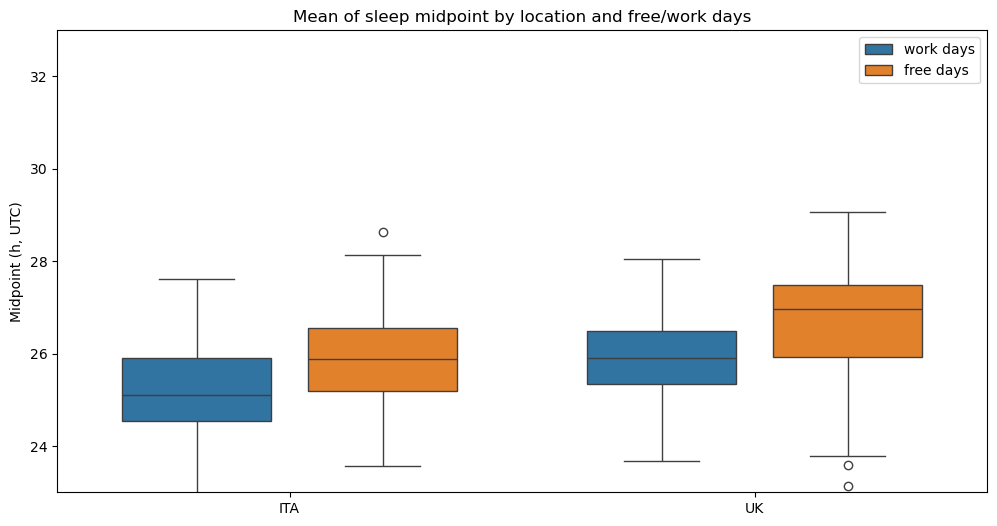

In [182]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='midpoint_h_UTC', hue='weekday_type', data=df, gap=0.2)
plt.title('Mean of sleep midpoint by location and free/work days')
plt.xlabel('')
plt.ylim(23, 33)
plt.ylabel('Midpoint (h, UTC)')
plt.legend()
plt.show()

In [183]:
model_work = smf.ols('midpoint_h_UTC ~ C(location) * photoperiod', data=df_workdays).fit()

In [184]:
model_work.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         midpoint_h_UTC   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     47.27
Date:                Wed, 13 Nov 2024   Prob (F-statistic):           3.26e-26
Time:                        17:26:02   Log-Likelihood:                -513.13
No. Observations:                 409   AIC:                             1034.
Df Residuals:                     405   BIC:                             1050.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        26.9534      0.283     95.078      0.000      26.396      27.511
C(location)[T.UK]                 0.5419      0.383      1.415      0.158      -0.211       1.294
photoperiod                      -0.1494      0.024     -6.300      0.000      -0.196      -0.103
C(location)[T.UK]:photoperiod     0.0114      0.032      0.359      0.720      -0.051       0.074
==============================================================================
Omnibus:                        2.960   Durbin-Watson:                   1.431
Prob(Omnibus):                  0.228   Jarque-Bera (JB):                2.374
Skew:                          -0.050   Prob(JB):                        0.305
Kurtosis:                       2.640   Cond. No.                         143.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [185]:
model_free = smf.ols('midpoint_h_UTC ~ C(location) * photoperiod', data=df_freedays).fit()

In [186]:
model_free.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         midpoint_h_UTC   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     15.56
Date:                Wed, 13 Nov 2024   Prob (F-statistic):           6.94e-09
Time:                        17:26:02   Log-Likelihood:                -230.41
No. Observations:                 157   AIC:                             468.8
Df Residuals:                     153   BIC:                             481.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        27.3850      0.555     49.320      0.000      26.288      28.482
C(location)[T.UK]                 1.6924      0.775      2.184      0.031       0.161       3.224
photoperiod                      -0.1248      0.046     -2.722      0.007      -0.215      -0.034
C(location)[T.UK]:photoperiod    -0.0879      0.065     -1.361      0.175      -0.216       0.040
==============================================================================
Omnibus:                        6.901   Durbin-Watson:                   1.862
Prob(Omnibus):                  0.032   Jarque-Bera (JB):                6.670
Skew:                          -0.496   Prob(JB):                       0.0356
Kurtosis:                       3.186   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

_Phase by location and week day_

In [187]:
data_phase2 = df.dropna(subset=['phase', 'location', 'weekday_type'])

In [188]:
glm_model_phase2 = smf.glm(
    formula="phase ~ location + weekday_type",
    data=data_phase2,
    family=sm.families.Gaussian()
)

In [189]:
# Fit of the model
glm_results_phase2 = glm_model_phase2.fit()

In [190]:
# Output the summary of the model (ita and free days as baseline)
glm_results_phase2_summary = glm_results_phase2.summary()
glm_results_phase2_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  phase   No. Observations:                  566
Model:                            GLM   Df Residuals:                      563
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          1.5307
Method:                          IRLS   Log-Likelihood:                -922.10
Date:                Wed, 13 Nov 2024   Deviance:                       861.81
Time:                        17:26:02   Pearson chi2:                     862.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2096
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.2096      0.107      1.963      0.050       0.000       0.419
location[T.UK]                0.9331      0.106      8.803      0.000       0.725       1.141
weekday_type[T.work days]    -0.8954      0.116     -7.705      0.000      -1.123      -0.668
=============================================================================================
"""

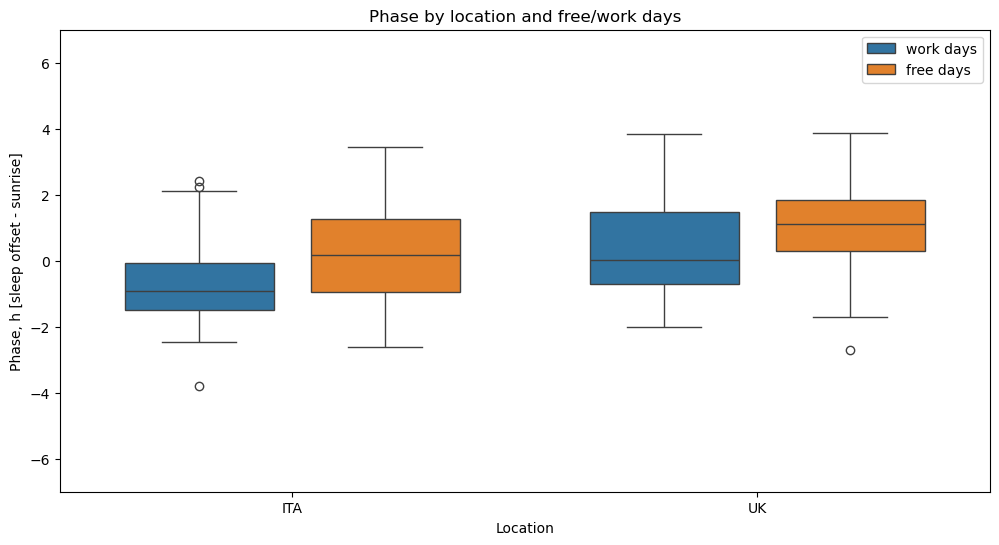

In [191]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='phase', hue='weekday_type', data=data_phase2, gap=0.2)
plt.title('Phase by location and free/work days')
plt.xlabel('Location')
plt.ylim(-7,7)
plt.ylabel('Phase, h [sleep offset - sunrise]')
plt.legend()

plt.show()

_Weekly IV, IS and RA_

In [192]:
# Load the datasets
weekly_values = pd.read_csv(fpath + '\\weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag_UTC

In [193]:
# Split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [194]:
# Convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [195]:
# Merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag_UTC,location
0,41,2022-10-12 to 2022-10-18,0.593843,0.089441,0.945319,2022-10-12,2022-10-18,24.491667,25.608333,-1.116667,ITA
1,41,2022-10-12 to 2022-10-18,0.593843,0.089441,0.945319,2022-10-12,2022-10-18,25.279167,25.637500,-0.358333,UK
2,42,2022-10-19 to 2022-10-25,0.592888,0.086393,0.934961,2022-10-19,2022-10-25,24.385417,25.045000,-0.659583,UK
3,43,2022-10-26 to 2022-11-01,0.615197,0.086685,0.958284,2022-10-26,2022-11-01,25.570833,26.237500,-0.666667,ITA
4,43,2022-10-26 to 2022-11-01,0.615197,0.086685,0.958284,2022-10-26,2022-11-01,23.129167,25.030208,-1.901042,UK


In [196]:
# Summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()
summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       53.0  0.080466  0.022129  0.024172  0.067942  0.082638  0.093785   
UK        36.0  0.088307  0.017596  0.053677  0.075609  0.087177  0.098561   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  53.0  0.534746  ...  0.614026  0.647358  52.0  0.934354   
UK        0.130562  36.0  0.546748  ...  0.612065  0.645810  36.0  0.916700   

                                                                      
               std       min       25%       50%       75%       max  
location                                                              
ITA       0.069393  0.480668  0.931915  0.942574  0.951111  1.097278  
UK        0.091243  0.480668  0.922486  0.941753  0.946843  0.962952  

[2 rows x 24 columns]

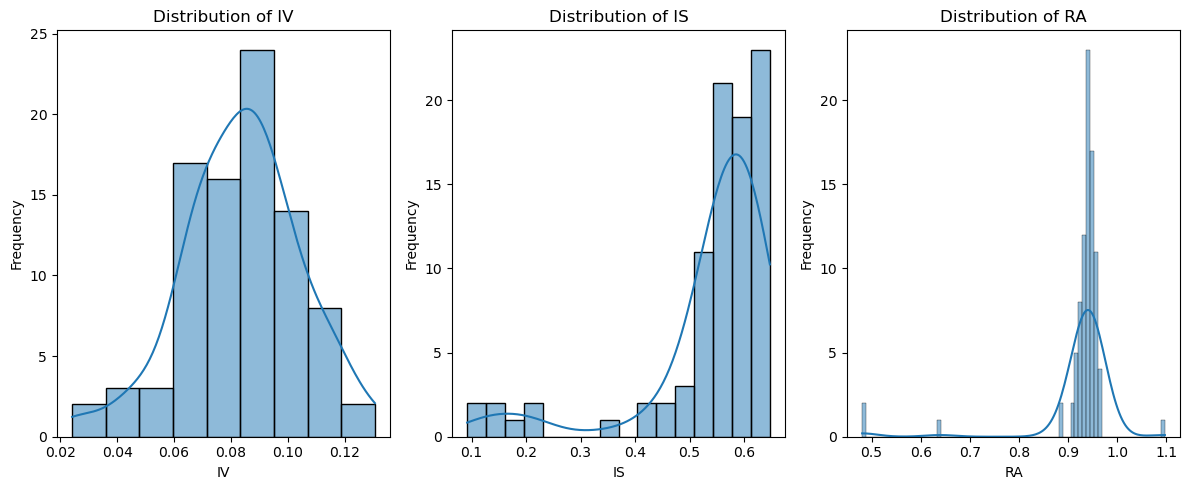

In [197]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title("Distribution of IV")
plt.xlabel("IV")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title("Distribution of RA")
plt.xlabel("RA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [198]:
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_ttest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [199]:
print("\nT-test results for IV by Location:", iv_ttest)
print("U-test results for IS by Location:", is_ttest)
print("T-test results for RA by Location:", ra_ttest)


T-test results for IV by Location: TtestResult(statistic=-1.7772445658632356, pvalue=0.07902284498496112, df=87.0)
U-test results for IS by Location: MannwhitneyuResult(statistic=968.0, pvalue=0.9101377845316613)
T-test results for RA by Location: TtestResult(statistic=1.0304626188970347, pvalue=0.30568225459077514, df=86.0)


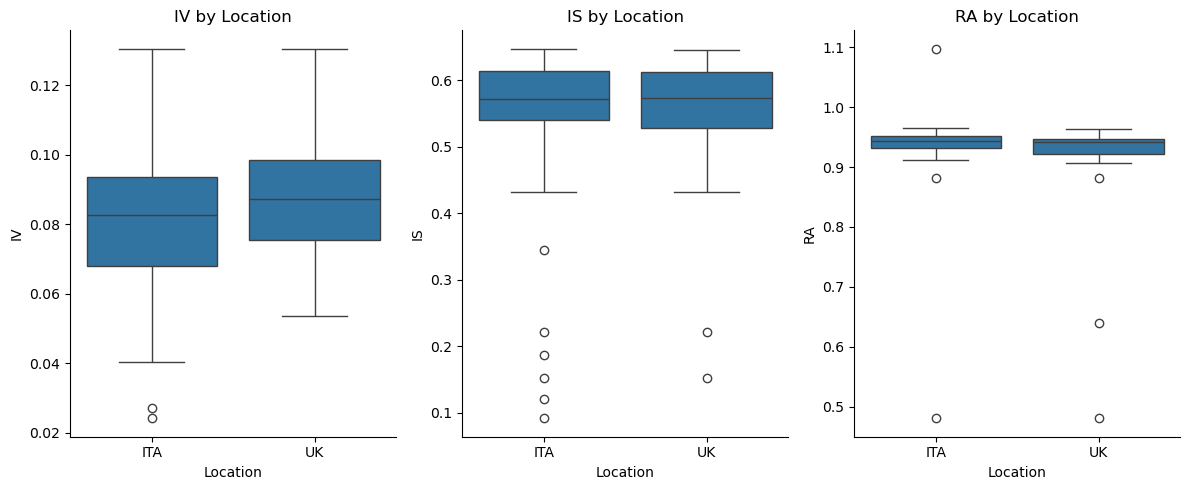

In [200]:
plt.figure(figsize=(12, 5))

# IV by Location
plt.subplot(1, 3, 1)
sns.boxplot(x="location", y="IV", data=merged_data)
plt.title("IV by Location")
plt.xlabel("Location")
plt.ylabel("IV")

# IS by Location
plt.subplot(1, 3, 2)
sns.boxplot(x="location", y="IS", data=merged_data)
plt.title("IS by Location")
plt.xlabel("Location")
plt.ylabel("IS")

plt.subplot(1, 3, 3)
sns.boxplot(x="location", y="RA", data=merged_data)
plt.title("RA by Location")
plt.xlabel("Location")
plt.ylabel("RA")

sns.despine()
plt.tight_layout()
plt.show()